In [1]:
import os
import pandas as pd
import numpy as np
import torch
#torchvision, torchaudio installed
from tqdm import tqdm

In [2]:
print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built()) #checks if your current PyTorch installation was compiled with support for the MPS backend

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
torch.mps.empty_cache()

2.10.0
True
True
Using device: mps


In [3]:
import warnings
import nltk
SEED = 0
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
warnings.filterwarnings('ignore')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jessie_guo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
from datasets import load_dataset
go_emotions = load_dataset("go_emotions")
print(go_emotions)
print(go_emotions['train'].features)

classes = go_emotions['train'].features['labels'].feature.names
print(f'\nClasses: {classes}')
len(classes)

train_data = pd.DataFrame(go_emotions['train'])
print(train_data)

counts = train_data['labels'].value_counts()
print(counts)
print(train_data['labels'])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}

Classes: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', '

In [51]:
#MAPPING -- adapted from superemotion dataset
import json
#Classes: [0'admiration', 1'amusement', 2'anger', 3'annoyance', 4'approval', 5'caring', 6'confusion', 
          #7'curiosity', 8'desire', 9'disappointment', 10'disapproval', 11'disgust', 12'embarrassment', 
          #13'excitement', 14'fear', 15'gratitude', 16'grief', 17'joy', 18'love', 19'nervousness', 20'optimism', 
          #21'pride', 22'realization', 23'relief', 24'remorse', 25'sadness', 26'surprise']
# ============================================================
# Shaver-style emotion reduction for GoEmotions
# ============================================================

shaver_mapping = {
    "love": [
        "admiration",
        "approval",
        "caring",
        "desire",
        "gratitude",
        "love"
    ],

    "joy": [
        "amusement",
        "curiosity",
        "excitement",
        "joy",
        "optimism",
        "pride",
        "relief"
    ],

    "anger": [
        "anger",
        "annoyance",
        "disapproval",
        "disgust"
    ],

    "sadness": [
        "disappointment",
        "embarrassment",
        "grief",
        "remorse",
        "sadness"
    ],

    "fear": [
        "fear",
        "nervousness"
    ],

    "surprise": [
        "confusion",
        "realization",
        "surprise"
    ],

    "neutral": [
        "neutral"
    ]
}

shaver_classes = list(shaver_mapping.keys())

shaver2id = {e: i for i, e in enumerate(shaver_classes)}
print(shaver2id)

goemotion_id_to_shaver = {
    0: "love", 1: "joy", 2: "anger", 3: "anger", 4: "love", 5: "love",                 
    6: "surprise", 7: "joy", 8: "love", 9: "sadness", 10: "anger", 11: "anger", 
    12: "sadness", 13: "joy", 14: "fear", 15: "love", 16: "sadness", 17: "joy", 
    18: "love", 19: "fear", 20: "joy", 21: "joy", 22: "surprise",
    23: "joy", 24: "sadness", 25: "sadness", 26: "surprise",
    27: "neutral"
}

def map_to_shaver(example):
    shaver_labels = set()

    for label in example["labels"]:
        shaver_category = goemotion_id_to_shaver[label]
        shaver_labels.add(shaver_category)
        
    multi_hot = [0] * len(shaver_classes)
    for e in shaver_labels:
        multi_hot[shaver2id[e]] = 1

    example["labels"] = multi_hot
    return example
         
reduced_emotions = go_emotions.map(map_to_shaver)

train_data = pd.DataFrame(reduced_emotions['train'])
print(train_data.head())

counts = train_data['labels'].value_counts()
print(counts)

{'love': 0, 'joy': 1, 'anger': 2, 'sadness': 3, 'fear': 4, 'surprise': 5, 'neutral': 6}


Map: 100%|███████████| 5427/5427 [00:00<00:00, 81330.33 examples/s]


                                                text                 labels  \
0  My favourite food is anything I didn't have to...  [0, 0, 0, 0, 0, 0, 1]   
1  Now if he does off himself, everyone will thin...  [0, 0, 0, 0, 0, 0, 1]   
2                     WHY THE FUCK IS BAYLESS ISOING  [0, 0, 1, 0, 0, 0, 0]   
3                        To make her feel threatened  [0, 0, 0, 0, 1, 0, 0]   
4                             Dirty Southern Wankers  [0, 0, 1, 0, 0, 0, 0]   

        id  
0  eebbqej  
1  ed00q6i  
2  eezlygj  
3  ed7ypvh  
4  ed0bdzj  
labels
[0, 0, 0, 0, 0, 0, 1]    12823
[1, 0, 0, 0, 0, 0, 0]     9844
[0, 1, 0, 0, 0, 0, 0]     5723
[0, 0, 1, 0, 0, 0, 0]     4929
[0, 0, 0, 1, 0, 0, 0]     2326
[0, 0, 0, 0, 0, 1, 0]     2217
[1, 1, 0, 0, 0, 0, 0]     1292
[0, 0, 0, 0, 1, 0, 0]      541
[0, 1, 0, 0, 0, 1, 0]      430
[1, 0, 0, 0, 0, 0, 1]      412
[0, 0, 1, 0, 0, 0, 1]      326
[1, 0, 0, 0, 0, 1, 0]      311
[0, 1, 0, 0, 0, 0, 1]      276
[0, 0, 1, 1, 0, 0, 0]      275
[0, 1,

In [5]:
# EKMAN MAPPING
import json
import pandas as pd
import numpy as np

with open("ekman_mapping.json", "r", encoding="utf-8") as f:
    ekman_mapping = json.load(f)

# Add neutral if not already present
ekman_mapping["neutral"] = ["neutral"]

# Broad Ekman classes
ekman_classes = list(ekman_mapping.keys())
ekman2id = {emotion: i for i, emotion in enumerate(ekman_classes)}

# Original GoEmotions label order
goemotion_classes = [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",
    "curiosity",
    "desire",
    "disappointment",
    "disapproval",
    "disgust",
    "embarrassment",
    "excitement",
    "fear",
    "gratitude",
    "grief",
    "joy",
    "love",
    "nervousness",
    "optimism",
    "pride",
    "realization",
    "relief",
    "remorse",
    "sadness",
    "surprise",
    "neutral"
]

# Reverse mapping: GoEmotions label name -> Ekman category
goemotion_to_ekman = {}

for ekman_category, goemotion_labels in ekman_mapping.items():
    for label in goemotion_labels:
        goemotion_to_ekman[label] = ekman_category

# Integer mapping: GoEmotions integer ID -> Ekman category
ekman_num = {
    i: goemotion_to_ekman[label]
    for i, label in enumerate(goemotion_classes)
}

print("Ekman mapping:")
print(ekman_mapping)

print("\nEkman classes:")
print(ekman_classes)

print("\nGoEmotion ID to Ekman category:")
print(ekman_num)

#multi-labelling
def map_to_ekman(example):
    ekman_labels = set()

    for label in example["labels"]:
        ekman_category = ekman_num[label]
        ekman_labels.add(ekman_category)
        
    multi_hot = [0] * len(ekman_classes)
    for e in ekman_labels:
        multi_hot[ekman2id[e]] = 1

    example["labels"] = multi_hot
    return example
         
reduced_emotions = go_emotions.map(map_to_ekman)

train_data = pd.DataFrame(reduced_emotions['train'])
print(train_data.head())

counts = train_data['labels'].value_counts()
print(counts)

Ekman mapping:
{'anger': ['anger', 'annoyance', 'disapproval'], 'disgust': ['disgust'], 'fear': ['fear', 'nervousness'], 'joy': ['joy', 'amusement', 'approval', 'excitement', 'gratitude', 'love', 'optimism', 'relief', 'pride', 'admiration', 'desire', 'caring'], 'sadness': ['sadness', 'disappointment', 'embarrassment', 'grief', 'remorse'], 'surprise': ['surprise', 'realization', 'confusion', 'curiosity'], 'neutral': ['neutral']}

Ekman classes:
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']

GoEmotion ID to Ekman category:
{0: 'joy', 1: 'joy', 2: 'anger', 3: 'anger', 4: 'joy', 5: 'joy', 6: 'surprise', 7: 'surprise', 8: 'joy', 9: 'sadness', 10: 'anger', 11: 'disgust', 12: 'sadness', 13: 'joy', 14: 'fear', 15: 'joy', 16: 'sadness', 17: 'joy', 18: 'joy', 19: 'fear', 20: 'joy', 21: 'joy', 22: 'surprise', 23: 'joy', 24: 'sadness', 25: 'sadness', 26: 'surprise', 27: 'neutral'}
                                                text                 labels  \
0  My favourite

In [6]:
print(reduced_emotions['train'][0:8])

{'text': ["My favourite food is anything I didn't have to cook myself.", 'Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead', 'WHY THE FUCK IS BAYLESS ISOING', 'To make her feel threatened', 'Dirty Southern Wankers', "OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.", 'Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝', 'We need more boards and to create a bit more space for [NAME]. Then we’ll be good.'], 'labels': [[0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0]], 'id': ['eebbqej', 'ed00q6i', 'eezlygj', 'ed7ypvh', 'ed0bdzj', 'edvnz26', 'ee3b6wu', 'ef4qmod']}


In [51]:
#data processing REDUCED CLASSES VERS.
from transformers import AutoTokenizer, DataCollatorWithPadding
PROBLEM_TYPE = "multi_label_classification"
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_labelling(examples):
    tokenized = tokenizer(
        examples['text'],
        truncation = True,
        padding = "max_length",
        max_length = 128)
    return tokenized

if PROBLEM_TYPE == "single_label_classification":
    def onehot_to_class(example):
        example["labels"] = int(np.argmax(example["labels"]))
        return example
    
    single_label_emotions = reduced_emotions.map(onehot_to_class)
    print(single_label_emotions["train"][0]["labels"])

def problem_type(reduced_dataset):
    tokenized_go_emotions = reduced_dataset.map(tokenize_labelling, 
                                        batched = True, 
                                        remove_columns = ["text"])
    return tokenized_go_emotions

if PROBLEM_TYPE == "single_label_classification":
    tokenized_go_emotions = problem_type(single_label_emotions)
elif PROBLEM_TYPE == "multi_label_classification":
    tokenized_go_emotions = problem_type(reduced_emotions)

print(pd.DataFrame(tokenized_go_emotions['train']))

tokenized_go_emotions.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"])

print(pd.DataFrame(tokenized_go_emotions['train']))
print(type(tokenized_go_emotions["train"][0]["labels"]))

class CustomDataCollator: #Only for multi-label classification
    def __call__(self, batch):
        input_ids = torch.stack([x["input_ids"] for x in batch])
        attention_mask = torch.stack([x["attention_mask"] for x in batch])
        labels = torch.stack([x["labels"] for x in batch]).to(torch.float32)  # important!
        return {"input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels}

data_collator = CustomDataCollator()
#dynamically pads each batch to longest sequence in batch rather than padding every sequence - saves compute, memory
#mlm=False to avoid randomly masking tokens

                      labels       id  \
0      [0, 0, 0, 0, 0, 0, 1]  eebbqej   
1      [0, 0, 0, 0, 0, 0, 1]  ed00q6i   
2      [1, 0, 0, 0, 0, 0, 0]  eezlygj   
3      [0, 0, 1, 0, 0, 0, 0]  ed7ypvh   
4      [1, 0, 0, 0, 0, 0, 0]  ed0bdzj   
...                      ...      ...   
43405  [0, 0, 0, 1, 0, 0, 0]  edsb738   
43406  [0, 0, 0, 0, 0, 1, 0]  ee7fdou   
43407  [1, 0, 0, 0, 0, 0, 0]  efgbhks   
43408  [0, 0, 0, 1, 0, 0, 0]  ed1naf8   
43409  [0, 0, 0, 1, 0, 0, 0]  eecwmbq   

                                               input_ids  \
0      [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134...   
1      [101, 2085, 2065, 2002, 2515, 2125, 2370, 1010...   
2      [101, 2339, 1996, 6616, 2003, 3016, 3238, 1116...   
3      [101, 2000, 2191, 2014, 2514, 5561, 102, 0, 0,...   
4      [101, 6530, 2670, 14071, 11451, 102, 0, 0, 0, ...   
...                                                  ...   
43405  [101, 2794, 2017, 6775, 2092, 1045, 1521, 2310...   
43406  [101, 2467, 2245, 20

In [52]:
print(tokenized_go_emotions["train"][0]["labels"])

tensor([0, 0, 0, 0, 0, 0, 1])


In [53]:
#Weights adjusted - initially produced worse results, so was not implemented in final model
if PROBLEM_TYPE == "multi_label_classification":
    y_train = np.array(tokenized_go_emotions["train"]["labels"])
    pos_counts = y_train.sum(axis=0)
    neg_counts = len(y_train) - pos_counts
    pos_weight = neg_counts/pos_counts
    pos_weight = torch.tensor(pos_weight, dtype = torch.float)
    print(pos_weight)

if PROBLEM_TYPE == "single_label_classification":
# Labels must be integer class IDs, e.g. [2, 0, 4, 1, ...]
    y_train = np.array(tokenized_go_emotions["train"]["labels"])
    
    num_classes = len(ekman_classes)
    class_counts = np.bincount(y_train, minlength=num_classes)
    
    # Balanced class weights
    class_weights = len(y_train) / (num_classes * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32)
    
    print("Class counts:", class_counts)
    print("Class weights:", class_weights)

tensor([ 6.7810, 53.7415, 58.7934,  1.4934, 12.3037,  7.0883,  2.0530])


In [21]:
#Weights adjusted - initially produced worse results, so was not implemented in final model
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

if PROBLEM_TYPE == "multi_label_classification":

    class WeightedTrainer(Trainer): #creates new class inheriting from Trainer
        def __init__(self, *args, pos_weight=None, **kwargs): #*args passes any number of positional arguments, **kwargs pass any number of keyword (named) arguments. 
            super().__init__(*args, **kwargs) #calls original Trainer
            self.pos_weight = pos_weight
    
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs): #rewrites the fn in Trainer
            labels = inputs.pop("labels").float() #removes target answer from inputs dict, need to reserve for validation
            outputs = model(**inputs)
            logits = outputs.logits #raw scores model produces before turned into probabilities
    
            loss_fct = nn.BCEWithLogitsLoss( #stand. loss for multi-labelling
                pos_weight = self.pos_weight.to(logits.device) #if rare label missed, multiply penalty by pos_weight, .to ensures weights moved to same loc as model
            )
            loss = loss_fct(logits, labels)
    
            return (loss, outputs) if return_outputs else loss #in case Trainer needs predictions for eval metrics

if PROBLEM_TYPE == "single_label_classification":

    class WeightedTrainer(Trainer):
        def __init__(self, *args, class_weights=None, **kwargs):
            super().__init__(*args, **kwargs)
            self.class_weights = class_weights
    
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").long() #stores integers
            outputs = model(**inputs)
            logits = outputs.logits
    
            loss_fct = nn.CrossEntropyLoss(
                weight=self.class_weights.to(logits.device)
            )
    
            loss = loss_fct(logits, labels)
    
            return (loss, outputs) if return_outputs else loss

In [54]:
from sklearn.metrics import f1_score, precision_score, recall_score
#For multi-label classification
def find_best_threshold(logits, labels):
    probs = 1/(1 + np.exp(-logits))
    best_t_micro = 0.5
    best_t_macro = 0.5
    best_t_weighted = 0.5
    best_f1_micro = 0
    best_f1_macro = 0
    best_f1_weighted = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs > t).astype(int)
        f1_micro = f1_score(labels, preds, average = "micro", zero_division = 0)
        f1_macro = f1_score(labels, preds, average = "macro", zero_division = 0)
        f1_weighted = f1_score(labels, preds, average = "weighted", zero_division = 0)
        if f1_micro > best_f1_micro:
            best_f1_micro = f1_micro
            best_t_micro = t
        if f1_macro > best_f1_macro:
            best_f1_macro = f1_macro
            best_t_macro = t
        if f1_weighted > best_f1_weighted:
            best_f1_weighted = f1_weighted
            best_t_weighted = t

    return best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted

In [55]:
print(PROBLEM_TYPE)

multi_label_classification


In [56]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support, hamming_loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if PROBLEM_TYPE == "multi_label_classification":

        best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted = find_best_threshold(logits, labels)
    
        probs = 1 / (1 + np.exp(-logits)) #remove for multi-class classification
    
        predictions = (probs > best_t_weighted).astype(int)  # Get the predicted class labels

        hamming_loss_score = hamming_loss(labels, predictions)

    elif PROBLEM_TYPE == "single_label_classification":

        predictions = logits.argmax(axis=-1)  # Get the predicted class labels

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    f1_micro = f1_score(labels, predictions, average = "micro", zero_division = 0)
    f1_macro = f1_score(labels, predictions, average = "macro", zero_division = 0)
    precision_micro = precision_score(labels, predictions, average="micro", zero_division=0)
    recall_micro = recall_score(labels, predictions, average="micro", zero_division=0)
    precision_macro = precision_score(labels, predictions, average="macro", zero_division=0)
    recall_macro = recall_score(labels, predictions, average="macro", zero_division=0)

    metrics_dict = {
        'f1_weighted': f1_weighted,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
    }

    if PROBLEM_TYPE == "multi_label_classification":
        metrics_dict.update({
            'hamming_loss_score': hamming_loss_score,
            'best_threshold': best_t_weighted
        })
    
    return metrics_dict

def training_model(TRAIN_OUTPUT, SAVE_OUPUT):
    model_1 = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", 
                                                                 num_labels = len(ekman_classes), #len(classes),  #len(shaver_classes)
                                                                 problem_type = PROBLEM_TYPE) #"single_label_classification" for multi-class classification #load the weights in saved dtype. Without, doubles memory usage if weights originally torch.bfloat16
    model_1.to(device)
    
    training_args = TrainingArguments(
        output_dir = TRAIN_OUTPUT,
        num_train_epochs = 10,
        per_device_train_batch_size = 32,
        gradient_accumulation_steps = 4, #accumulate gradients across several batches and update once as opposed to updating weights every batch, simulates training with large batch size w/o storing, saves memory but slower training
        #gradient_checkpointing=True, #recomputes intermediate activations during forward pass as opposed to storing - extra computation but saves memory
        fp16 = False, #bf16 for fast mixed precision training, fp16 false for mps
        learning_rate = 2e-5, #initial lr
        logging_steps = 100, #controls how frequently to update + return loss
        eval_strategy = "epoch", #when to evaluate a model during training
        save_strategy = "epoch", #when to save
        weight_decay = 0.01, #L2 regularisation, helps prevent model from overfitting by discouraging large weights - uses AdamW, independent of weight updates --> better training stability
        metric_for_best_model = 'eval_f1_weighted',
        greater_is_better = True,
        load_best_model_at_end = True,
        save_total_limit = 2
    )
    
    trainer_kwargs = {
        "model": model_1,
        "args": training_args,
        "train_dataset": tokenized_go_emotions["train"],
        "eval_dataset": tokenized_go_emotions["validation"],
        "processing_class": tokenizer,
        "compute_metrics": compute_metrics,
        "callbacks": [EarlyStoppingCallback(early_stopping_patience=3)],
    }
    
    if PROBLEM_TYPE == "multi_label_classification":
        trainer_kwargs["data_collator"] = data_collator
    #    trainer_kwargs["pos_weight"] = pos_weight #remove if not using weightedtrainer

    #if PROBLEM_TYPE == "single_label_classification":
    #    trainer_kwargs["class_weights"] = class_weights #remove if not using weightedtrainer
    
    trainer = Trainer(**trainer_kwargs) #Trainer otherwise
    trainer.train()
    
    trainer.save_model(SAVE_OUPUT)
    tokenizer.save_pretrained(SAVE_OUPUT)

    return trainer

In [57]:
trainer_multilabel = training_model("distilbert_finetuned-goemotions_ekman_multilabel", "distilbert_finetuned-goemotions-final_ekman_multilabel")

Loading weights: 100%|█████████| 100/100 [00:00<00:00, 8124.09it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Weighted,Precision Weighted,Recall Weighted,F1 Micro,Precision Micro,Recall Micro,F1 Macro,Precision Macro,Recall Macro,Hamming Loss Score,Best Threshold
1,0.982576,0.231871,0.674126,0.614652,0.759040,0.679834,0.615595,0.759040,0.559565,0.589682,0.584588,0.111395,0.250000
2,0.854005,0.215021,0.703876,0.667644,0.749240,0.705770,0.667068,0.749240,0.622018,0.636670,0.623871,0.097336,0.300000
3,0.775580,0.212060,0.706580,0.662296,0.765799,0.706249,0.655292,0.765799,0.629512,0.619672,0.650318,0.099258,0.300000
4,0.721085,0.216713,0.705677,0.643065,0.786076,0.703144,0.636040,0.786076,0.635495,0.592128,0.692129,0.103417,0.250000
5,0.661066,0.227753,0.696573,0.637618,0.771544,0.693236,0.629359,0.771544,0.622654,0.566717,0.696152,0.106393,0.250000
6,0.592912,0.235562,0.694069,0.640244,0.759885,0.691740,0.634811,0.759885,0.621588,0.575676,0.679135,0.105524,0.250000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.83it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.55it/s]


In [27]:
trainer_multiclass = training_model("distilbert_finetuned-goemotions_ekman_multiclass_weighted", "distilbert_finetuned-goemotions-final_ekman_multiclass_weighted")

Loading weights: 100%|█████████| 100/100 [00:00<00:00, 7849.94it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Weighted,Precision Weighted,Recall Weighted,F1 Micro,Precision Micro,Recall Micro,F1 Macro,Precision Macro,Recall Macro
1,4.334814,1.034983,0.646333,0.678715,0.635459,0.635459,0.635459,0.635459,0.573930,0.536563,0.662354
2,3.692425,0.993168,0.650068,0.681562,0.641725,0.641725,0.641725,0.641725,0.571766,0.527893,0.672780
3,3.173433,1.005165,0.646709,0.681662,0.639882,0.639882,0.639882,0.639882,0.565920,0.523263,0.671593
4,2.835900,1.035020,0.647094,0.683332,0.637855,0.637855,0.637855,0.637855,0.566999,0.530496,0.660179
5,2.486705,1.065314,0.668825,0.691883,0.660892,0.660892,0.660892,0.660892,0.596804,0.562555,0.654346
6,2.216706,1.119856,0.663540,0.686262,0.656837,0.656837,0.656837,0.656837,0.593839,0.562208,0.648915
7,1.946200,1.165211,0.661708,0.683963,0.656285,0.656285,0.656285,0.656285,0.590938,0.562340,0.644679
8,1.888466,1.200193,0.663885,0.683162,0.658865,0.658865,0.658865,0.658865,0.590948,0.564922,0.635699


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.82it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.50it/s]


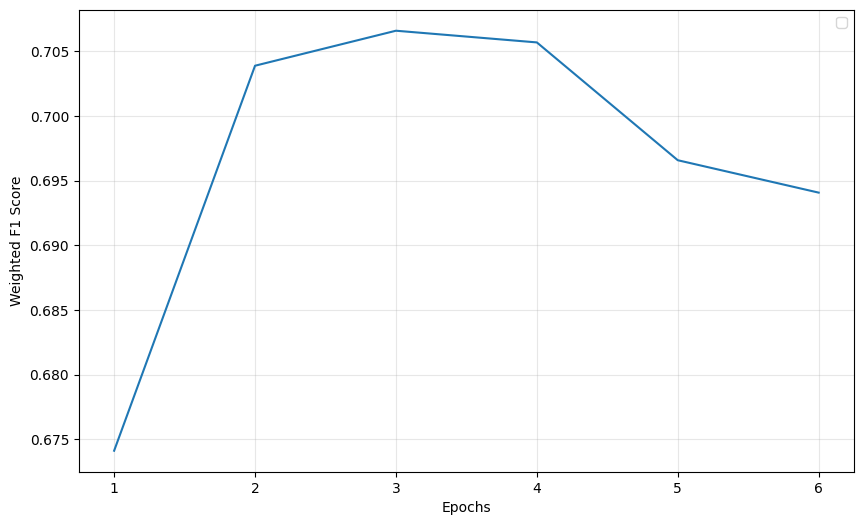

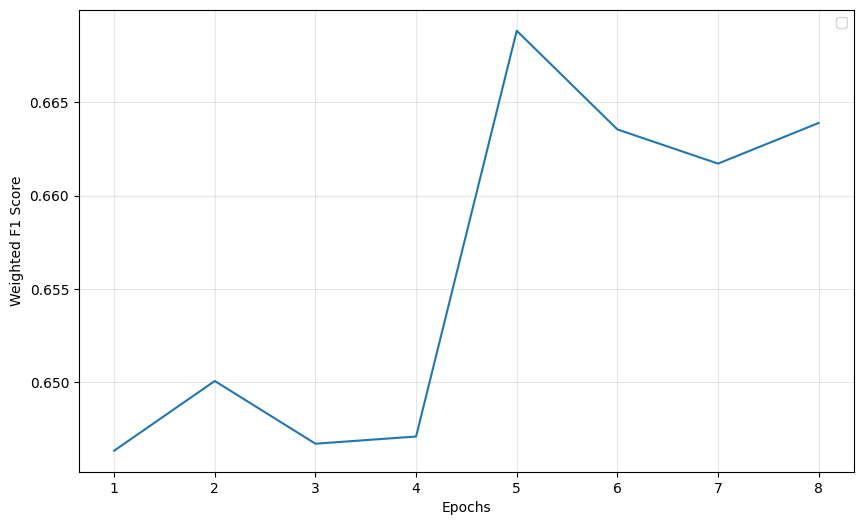

In [58]:
#Training and Validation Loss, Weighted_F1 Curves
import matplotlib.pyplot as plt
import pandas as pd

def loss_curves_and_weighted_f1(trainer, model_name):
    if trainer == trainer_multilabel:
        history = trainer.state.log_history
    if trainer == trainer_multiclass:
        history = trainer.state.log_history
    df = pd.DataFrame(history)
    
    train_df = df[df['loss'].notna()]
    eval_df = df[df['eval_loss'].notna()]
    weighted_f1_df = df[df['eval_f1_weighted'].notna()]
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(train_df['epoch'], train_df['loss'], label='Training Loss')
    plt.plot(eval_df['epoch'], eval_df['eval_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{model_name}_training_validation_loss")
    plt.clf()
    
    plt.plot(weighted_f1_df['epoch'], weighted_f1_df['eval_f1_weighted'])
    plt.xlabel('Epochs')
    plt.ylabel('Weighted F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{model_name}_weighted_f1.png")

loss_curves_and_weighted_f1(trainer_multilabel, "Multi-label_Classification")
loss_curves_and_weighted_f1(trainer_multiclass, "Multi-class_Classification")


In [59]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback

SAVE_OUTPUT = "distilbert_finetuned-goemotions-final_ekman_multilabel_val"

def save_to_device(SAVE_OUTPUT):
    model_new = AutoModelForSequenceClassification.from_pretrained(SAVE_OUTPUT)
    tokenizer_new = AutoTokenizer.from_pretrained(SAVE_OUTPUT)
    return model_new, tokenizer_new

model_new, tokenizer_new = save_to_device(SAVE_OUTPUT)

model_new.to(device)
model_new.eval()

Loading weights: 100%|█████████| 104/104 [00:00<00:00, 8119.27it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [45]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        self.texts = dataframe['text']
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts.iloc[index])
        text = " ".join(text.split())
        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,  # Add special tokens
            max_length=self.max_len,
            padding='max_length',  # Pad to max_length
            return_token_type_ids=True,
            return_tensors='pt',  # Return PyTorch tensors
            truncation=True  # Truncate sequences longer than max_length
        )
        
        input_ids = inputs['input_ids'].squeeze(0)  # Remove the added batch dimension
        attention_mask = inputs['attention_mask'].squeeze(0)  # Remove the added batch dimension
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
        }

In [46]:

def test():
    model_new.eval()
    all_outputs = []
    with torch.no_grad():
        for data in test_loader:
            input_ids = data['input_ids'].to(device) #, dtype=torch.long)
            attention_mask = data['attention_mask'].to(device) #, dtype=torch.long)
            outputs = model_new(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits

            if PROBLEM_TYPE == "multi_label_classification":
                probs = torch.sigmoid(logits)
                all_outputs.extend(probs.cpu().numpy().tolist())
            elif PROBLEM_TYPE == "single_label_classification":
                probs = torch.softmax(logits, dim = -1)
                predictions = torch.argmax(probs, dim = -1)
                all_outputs.extend(predictions.cpu().numpy().tolist())  
    
    return all_outputs

In [47]:
lengths = [len(tokenizer_new.encode(text)) for text in go_emotions['train']['text']]
print(max(lengths)) #max token count across all texts
print("95th percentile:", np.percentile(lengths, 95)) #95% of samples contain 34 tokens or fewer 

MAX_LEN = 128

316
95th percentile: 34.0


In [60]:
#preliminary test evaluations
texts_path = 'Data/Georgian/Vazha_ThreePoems/'
sources = ['en', 'orig', 'gem', 'ggl', 'gpt']
poems_path = texts_path
poem_names = []

output_base = "results/poems/sentiment/"
os.makedirs(output_base, exist_ok=True)

ge_poems_directory = os.fsencode(poems_path + 'en')
for file in sorted(os.listdir(ge_poems_directory)):
    file = file.decode()
    if file.endswith(".md"):
        poem_names.append(file)

print(poem_names)

['06_that_in_truth_is_not_manliness.md']


In [61]:
from torch.utils.data import DataLoader

PROBLEM_TYPE = "multi_label_classification"

for source in sources:
    output_dir = os.path.join(output_base, source)
    os.makedirs(output_dir, exist_ok = True)
    
    for poem in poem_names:
        input_file = os.path.join(poems_path, source, poem)
        
        poem_text = [line.strip() for line in open(input_file, "r")]
        poem_df = pd.DataFrame(poem_text, columns=['text'])
        test_dataset = CustomDataset(poem_df, tokenizer_new, MAX_LEN)
        test_params = {'batch_size': 1, 'shuffle': False, 'num_workers': 0}
        test_loader = DataLoader(test_dataset, **test_params)
        
        if PROBLEM_TYPE == "multi_label_classification":
            test_probs = np.array(test())
        
            test_outputs = (test_probs >= 0.3).astype(int)    
        
            for j, label in enumerate(ekman_classes): #ekman_classes
                poem_df[label] = test_outputs[:, j]
        
        elif PROBLEM_TYPE == "single_label_classification":
            test_predictions = np.array(test())

            poem_df["predicted_label_id"] = test_predictions
    
            poem_df["predicted_label"] = [ekman_classes[i] for i in test_predictions] #ekman_classes

        output_file = os.path.join(output_dir, poem)
        poem_df.to_csv(output_file)

FileNotFoundError: [Errno 2] No such file or directory: 'Data/Georgian/Vazha_ThreePoems/orig/06_that_in_truth_is_not_manliness.md'

In [62]:
#Ekman classes

t01 = pd.read_csv("results/poems/sentiment/en/06_that_in_truth_is_not_manliness.md")
t01_text = t01["text"]
print(t01_text)

if PROBLEM_TYPE == "multi_label_classification":

    manual_labels = [
        ["neutral", "disgust"],
        ["neutral", "disgust"],
        ["neutral", "disgust"],
        ["neutral"],
        ["anger"],
        ["neutral"],
        ["disgust", "neutral"],
        ["neutral", "disgust"],
        ["disgust"],
        ["neutral"]
    ]

    t01["manual_label"] = manual_labels
    
    for label in ekman_classes:
        t01[f"manual_{label}"] = 0
    
    for i, labels_for_row in enumerate(manual_labels):
        for label in labels_for_row:
            if label in ekman_classes:
                t01.at[i, f"manual_{label}"] = 1
            else:
                print(f"Invalid label in row {i}: {label}")
    
    manual_cols = [f"manual_{label}" for label in ekman_classes]
    pred_cols = ekman_classes
    print(t01)
    
    y_true = t01[manual_cols].astype(int).values
    y_pred = t01[pred_cols].astype(int).values

elif PROBLEM_TYPE == "single_label_classification":
    t01["manual_label"] = [
    "neutral",
    "neutral",
    "neutral",
    "neutral",
    "anger",
    "neutral",
    "disgust",
    "disgust",
    "disgust",
    "neutral",
]

    label_to_id = {label: i  for i, label in enumerate (ekman_classes)}
    
    t01["manual_label_id"] = t01["manual_label"].map(label_to_id)
    print(t01)
    
    y_true = t01["manual_label_id"].values
    y_pred = t01["predicted_label_id"].values

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
f1_micro = f1_score(y_true, y_pred, average = "micro", zero_division = 0)
f1_macro = f1_score(y_true, y_pred, average = "macro", zero_division = 0)
precision_micro = precision_score(y_true, y_pred, average="micro", zero_division=0)
recall_micro = recall_score(y_true, y_pred, average="micro", zero_division=0)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)

print(
    'f1_weighted:', f1_weighted,
    '\nprecision_weighted:', precision_weighted,
    '\nrecall_weighted:', recall_weighted,
    '\nf1_micro:', f1_micro,
    '\nprecision_micro:', precision_micro,
    '\nrecall_micro:', recall_micro,
    '\nf1_macro:', f1_macro,
    '\nprecision_macro:', precision_macro,
    '\nrecall_macro:', recall_macro,
)

0    That in truth is not manliness When someone eg...
1    A man would I call you only if Of your own inc...
2    Nor to call it manliness would I wish When you...
3    A man would I call you only when One throttled...
4    Tell me, who has styled it manly virtue When i...
5    Rather is it true manliness When you suffer fo...
6    And no manliness begins When with full stomach...
7    Or when you behave as superior to others, And ...
8    When from your minstrelsy you give none peace ...
9    A man then surely would I call you Were you to...
Name: text, dtype: object
   Unnamed: 0                                               text  anger  \
0           0  That in truth is not manliness When someone eg...      0   
1           1  A man would I call you only if Of your own inc...      0   
2           2  Nor to call it manliness would I wish When you...      1   
3           3  A man would I call you only when One throttled...      0   
4           4  Tell me, who has styled it manly v

In [43]:
#Shaver classes
t01 = pd.read_csv("results/poems/sentiment/en/06_that_in_truth_is_not_manliness.md")
t01_text = t01["text"]
print(t01_text)

if PROBLEM_TYPE == "multi_label_classification":
  
    manual_labels = [
        ["neutral", "sadness"],
        ["neutral", "sadness"],
        ["neutral", "anger"],
        ["neutral", "sadness"],
        ["anger"],
        ["neutral", "sadness"],
        ["neutral", "sadness"],
        ["sadness", "anger"],
        ["sadness", "anger"],
        ["neutral"]
    ]

    t01["manual_label"] = manual_labels
    
    for label in shaver_classes:
        t01[f"manual_{label}"] = 0
    
    for i, labels_for_row in enumerate(manual_labels):
        for label in labels_for_row:
            if label in shaver_classes:
                t01.at[i, f"manual_{label}"] = 1
            else:
                print(f"Invalid label in row {i}: {label}")
    
    manual_cols = [f"manual_{label}" for label in shaver_classes]
    pred_cols = shaver_classes
    print(t01)
    
    y_true = t01[manual_cols].astype(int).values
    y_pred = t01[pred_cols].astype(int).values

elif PROBLEM_TYPE == "single_label_classification":
    t01["manual_label"] = [
    "sadness",
    "neutral",
    "anger",
    "neutral",
    "anger",
    "sadness",
    "sadness",
    "sadness",
    "anger",
    "neutral",
]

    label_to_id = {label: i  for i, label in enumerate (shaver_classes)}
    
    t01["manual_label_id"] = t01["manual_label"].map(label_to_id)
    print(t01)
    
    y_true = t01["manual_label_id"].values
    y_pred = t01["predicted_label_id"].values

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
f1_micro = f1_score(y_true, y_pred, average = "micro", zero_division = 0)
f1_macro = f1_score(y_true, y_pred, average = "macro", zero_division = 0)
precision_micro = precision_score(y_true, y_pred, average="micro", zero_division=0)
recall_micro = recall_score(y_true, y_pred, average="micro", zero_division=0)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)

print(
    'f1_weighted:', f1_weighted,
    '\nprecision_weighted:', precision_weighted,
    '\nrecall_weighted:', recall_weighted,
    '\nf1_micro:', f1_micro,
    '\nprecision_micro:', precision_micro,
    '\nrecall_micro:', recall_micro,
    '\nf1_macro:', f1_macro,
    '\nprecision_macro:', precision_macro,
    '\nrecall_macro:', recall_macro,
)

0    That in truth is not manliness When someone eg...
1    A man would I call you only if Of your own inc...
2    Nor to call it manliness would I wish When you...
3    A man would I call you only when One throttled...
4    Tell me, who has styled it manly virtue When i...
5    Rather is it true manliness When you suffer fo...
6    And no manliness begins When with full stomach...
7    Or when you behave as superior to others, And ...
8    When from your minstrelsy you give none peace ...
9    A man then surely would I call you Were you to...
Name: text, dtype: object


NameError: name 'shaver_classes' is not defined